<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Tackle Imbalanced Data Challenge**


## **Introduction**

In many classification problems, one class appears much more often than the other class. This is called **imbalanced data**. For example, most credit card transactions are normal, and only a very small number are fraud cases.

Imbalanced data can make a model look better than it really is. A model may get high accuracy by mostly predicting the majority class, but it may still miss many important minority-class examples.

In this lab, you will study four binary classification scenarios with different levels of class imbalance:


| Task Name     | Class Ratio (Negative vs. Positive)  |
| ------------- |:-------------:|
| _Credit Card Fraud Detection_      | ~1000 : 1      | 
| _Predicting Customer Churn_ | ~5 : 1      | 
| _Tumor Type Estimation_ | ~2 : 1     | 
| _Predicting Job Change_ | ~10 : 1      | 


There is no single method that solves every imbalanced-data problem. Different methods help with different parts of the problem.

For example, stratification is useful when we split the data. In `train_test_split`, using `stratify=y` keeps the class ratio similar in the training and test sets. In cross-validation, using stratified folds, such as `StratifiedKFold`, keeps the class ratio similar in each fold. This makes evaluation fairer.

However, stratification does not change how the model learns. If the training data still has very few positive examples, the model may still mostly learn the majority class.

Some models also let us specify class imbalance directly with `class_weight`. This helps because it makes mistakes on the minority class more costly during training. However, class weighting may not always be enough, so we also try resampling methods.

In this lab, you will compare several ways to handle imbalanced data:

- **Better evaluation metrics**: Accuracy can be misleading on imbalanced data. This lab uses precision, recall, F-score, and AUC to evaluate models more carefully.
- **Stratified splitting and cross-validation**: Keep the class ratio similar in the training/test split and in each cross-validation fold, so evaluation is fairer.
- **Class reweighting**: Give the minority class a larger weight during training, so the model pays more attention to it.
- **SMOTE oversampling**: Create new synthetic minority-class examples to make the training data more balanced.
- **Random undersampling**: Remove some majority-class examples to make the training data more balanced.
- **Model comparison**: Train models on the original data, class-weighted data, SMOTE data, and undersampled data, then compare their results.

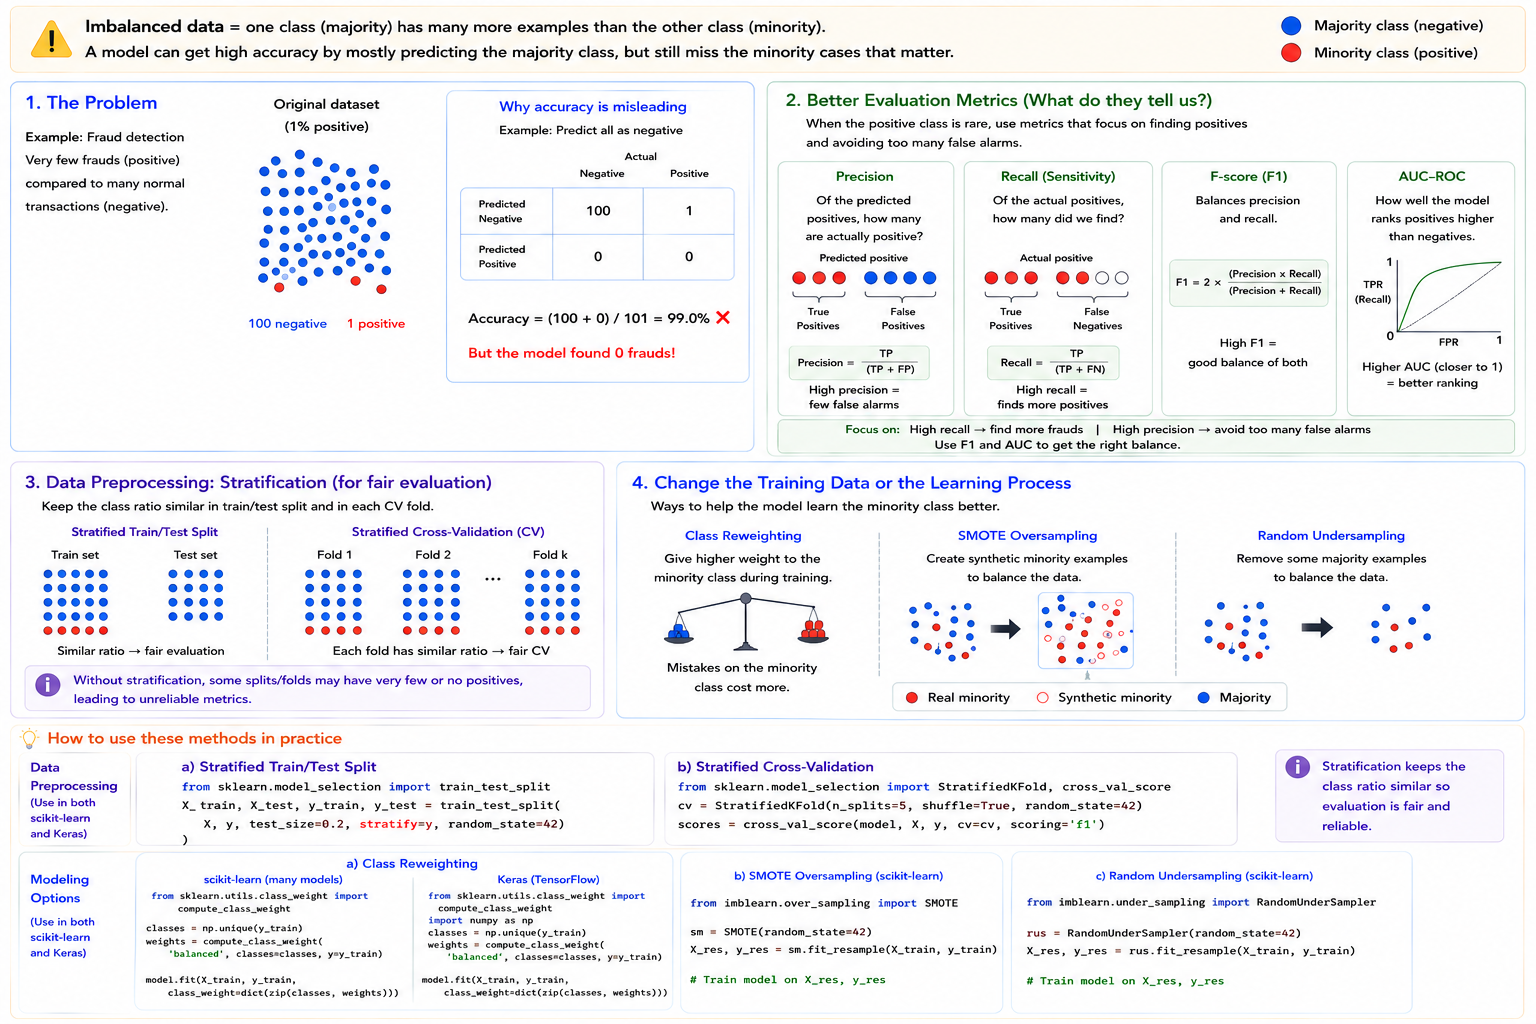

## **Objectives**


* Identify typical patterns of imbalanced data challenges
* Apply `Class Re-weighting` method to adjust the impacts of different classes in model training processes
* Apply `Oversampling` and `Undersampling` to generate synthetic datasets and rebalance classes
* Evaluate your consolidated classifiers using robust metrics such as `F-score` and `AUC`


----


## **Workflow**
### **Setup**
First, let us import the required packages for this lab:


In [ ]:
## Import packages here
import pandas as pd
import numpy as np
import imblearn
from matplotlib.pyplot import figure
from sklearn.utils import shuffle
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.under_sampling import RandomUnderSampler

from sklearn import metrics
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from collections import Counter

First, we want to provide some sample grid search methods if you are interested in tuning your model


In [ ]:
rs = 123


# Grid search hyperparameters for a logistic regression model
def grid_search_lr(X_train, y_train):
    params_grid = {
        "class_weight": [{0: 0.05, 1: 0.95}, {0: 0.1, 1: 0.9}, {0: 0.2, 1: 0.8}]
    }
    lr_model = LogisticRegression(random_state=rs, max_iter=1000)
    grid_search = GridSearchCV(
        estimator=lr_model,
        param_grid=params_grid,
        scoring="f1",
        cv=5,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    return best_params


# Grid search hyperparameters for a random forest model
def grid_search_rf(X_train, y_train):
    params_grid = {
        "max_depth": [5, 10, 15, 20],
        "n_estimators": [25, 50, 100],
        "min_samples_split": [2, 5],
        "class_weight": [{0: 0.1, 1: 0.9}, {0: 0.2, 1: 0.8}, {0: 0.3, 1: 0.7}],
    }
    rf_model = RandomForestClassifier(random_state=rs)
    grid_search = GridSearchCV(
        estimator=rf_model,
        param_grid=params_grid,
        scoring="f1",
        cv=5,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    return best_params

and a method to split training and testing dataset


In [ ]:
def split_data(df):
    X = df.loc[:, df.columns != "Class"]
    y = df["Class"].astype("int")
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=rs)

### **Scenario 1: Credit Card Fraud Detection**


We start with a credit card fraud detection task.
Most credit card transactions are normal, and only a very small number are fraud. Our goal is to train a model that can identify the fraud transactions, even though they are rare.


First, load the dataset as a dataframe:


In [ ]:
credit_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML201EN-SkillsNetwork/labs/module_4/datasets/im_credit.csv",
    index_col=False,
)

In [63]:
credit_df.head()

,V14,V17,V4,V10,V28,Class
0,0.423619,-0.210863,0.933459,0.027866,0.019308,0
1,0.986727,0.174009,-2.019905,-1.620065,-0.307753,0
2,-0.023094,-0.541985,-0.902618,-0.192212,-0.048965,0
3,-0.152111,-0.615094,1.276126,-0.026822,0.044480,0
4,-0.535807,-0.248563,4.517539,1.871441,0.120955,0


For privacy reasons, the original transaction details are hidden. The dataset contains numerical features created from a PCA transformation, plus the target column `Class`.


Next, check the class distribution:


In [ ]:
credit_df["Class"].value_counts()

Class
0    200000
1       200
Name: count, dtype: int64

<Axes: xlabel='Class'>

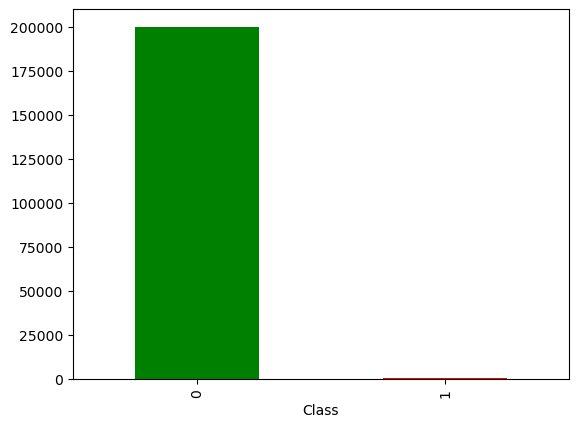

In [ ]:
# Visualize the count for each class
credit_df["Class"].value_counts().plot.bar(color=["green", "red"])

The fraud class is much smaller than the normal class. This makes the dataset extremely imbalanced, so accuracy alone can be misleading.


Now train a standard logistic regression model as a baseline.


In [66]:
# Split the training and testing dataset
X_train, X_test, y_train, y_test = split_data(credit_df)

In [ ]:
# Build a simple logistic regression model
model = LogisticRegression(random_state=rs, max_iter=1000)

# Train the model
model.fit(X_train, y_train)
preds = model.predict(X_test)

Check the model's accuracy:


In [68]:
accuracy_score(y_test, preds)

0.9992757242757243

The accuracy is very high, but that does not mean the model is good at finding fraud. With imbalanced data, a model can get high accuracy by mostly predicting the majority class. We need more useful metrics.


#### **More Robust Evaluation Metrics**


For imbalanced binary classification, precision, recall, F-score, and AUC are more informative than accuracy:


- `Precision`: among the transactions predicted as fraud, the percentage that are truly fraud.

- `Recall`: among all real fraud transactions, the percentage the model finds.

- `F-score`: a weighted balance between precision and recall. The `beta` value controls how much recall is emphasized.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML201EN-SkillsNetwork/labs/module_4/images/evaluation_metrics.png" width="720" alt="evaluation metrics">
</center>


`ROC` shows the trade-off between true positives and false positives at different thresholds. `AUC` summarizes that curve into one score.


Calculate the metrics for the baseline model:


In [ ]:
# Calculate the precision, recall, f5 given the y_test and predictions
# Note that we use beta=5 which means we think the cost of positive class is 5 times of negative class
# You could try other beta values yourself
accuracy = accuracy_score(y_test, preds)
precision, recall, fbeta, support = precision_recall_fscore_support(
    y_test, preds, beta=5, pos_label=1, average="binary"
)
auc = roc_auc_score(y_test, preds)
print(f"Accuracy is: {accuracy:.2f}")
print(f"Precision is: {precision:.2f}")
print(f"Recall is: {recall:.2f}")
print(f"Fscore is: {fbeta:.2f}")
print(f"AUC is: {auc:.2f}")

Accuracy is: 1.00
Precision is: 0.72
Recall is: 0.45
Fscore is: 0.46
AUC is: 0.72


For fraud detection, recall is usually very important. Missing a fraud transaction can be costly, while a false alarm may only require an extra check with the customer.

So our first goal is to improve recall. At the same time, we still want precision to stay as high as possible.


#### **Synthetic Minority Oversampling Technique (SMOTE)**


SMOTE is an oversampling method. It creates new synthetic minority-class examples by looking at existing minority examples and their nearby neighbors.
The goal is to give the model more fraud-like examples during training.

Unlike simple duplication, SMOTE creates new examples instead of copying the same rows again.


The `imblearn` package provides several resampling tools, including `SMOTE`, `RandomOverSampler`, and `RandomUnderSampler`. Here we use `SMOTE`.


In [70]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [ ]:
# Create a SMOTE sampler
smote_sampler = SMOTE(random_state=rs)

In [72]:
# Resample training data using SMOTE
X_smo, y_smo = smote_sampler.fit_resample(X_train, y_train)

After SMOTE, the training data has the same number of fraud and normal examples.


<Axes: xlabel='Class'>

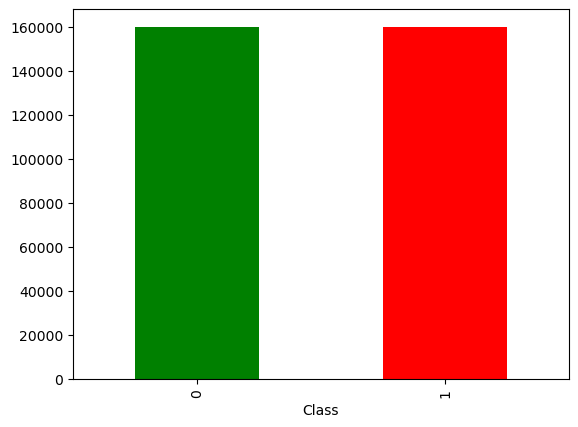

In [ ]:
# Visualize classes
y_smo.value_counts().plot.bar(color=["green", "red"])

Retrain logistic regression using the SMOTE-resampled training data.


In [74]:
# Re-train the model with resampled data
model.fit(X_smo, y_smo)
preds = model.predict(X_test)

Then evaluate the model again.


In [ ]:
# Calculate the precision, recall, f5 given the y_test and predictions
# Note that we use beta=5 which means we think the cost of positive class is 5 times of negative class
# You could try other beta values yourself
precision, recall, f_beta, support = precision_recall_fscore_support(
    y_test, preds, beta=5, pos_label=1, average="binary"
)
auc = roc_auc_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
print(f"Accuracy is: {accuracy:.2f}")
print(f"Precision is: {precision:.2f}")
print(f"Recall is: {recall:.2f}")
print(f"Fscore is: {f_beta:.2f}")
print(f"AUC is: {auc:.2f}")

Accuracy is: 0.97
Precision is: 0.03
Recall is: 0.88
Fscore is: 0.42
AUC is: 0.92


After SMOTE, AUC improves. This means the model separates fraud and normal transactions better than before.


Recall also improves a lot, so the model finds more fraud transactions.


However, precision becomes very low. This means many transactions predicted as fraud are actually normal. One reason is that SMOTE changes the training distribution a lot when the original dataset is extremely imbalanced.


For extremely imbalanced data, oversampling can improve recall but may create too many false positives.


Next, try class reweighting to see whether it gives a better balance between recall and precision.


#### **Class reweighting**


By default, many classifiers treat mistakes from both classes equally.

In an imbalanced dataset, this can cause the model to focus too much on the majority class. Class reweighting fixes this by giving the minority class a larger weight during training.


Class weights can be chosen in several ways:


- Use the class proportions in the dataset.
- Use domain knowledge about the cost of each mistake.
- Tune the weights with grid search or cross-validation.


`sklearn` makes this easy with the `class_weight` argument. Models such as `LogisticRegression` and `RandomForestClassifier` support it.


Here is an example using `LogisticRegression`:


First, create a class-weight dictionary.


In [76]:
class_weight = {}

# Assign weight of class 0 to be 0.1
class_weight[0] = 0.1

# Assign weight of class 1 to be 0.9
class_weight[1] = 0.9

The `0.1` and `0.9` values are pre-tuned for this example. You can also use `grid_search_lr()` to search for better weights.


Now pass the dictionary to the `class_weight` argument.


In [ ]:
# Define a logistic regression with weight
model = LogisticRegression(
    random_state=rs, max_iter=1000, class_weight=class_weight
)

During training, mistakes on the fraud class now have more influence. This should help the model find more fraud transactions.


In [78]:
# Train the model
model.fit(X_train, y_train)
# Make predictions on the test dataset
preds = model.predict(X_test)

Evaluate the class-weighted model.


In [ ]:
# Calculate the precision, recall, f5 given the y_test and predictions
# Note that we use beta=5 which means we think the cost of positive class is 5 times of negative class
# You could try other beta values yourself
precision, recall, f_beta, support = precision_recall_fscore_support(
    y_test, preds, beta=5, pos_label=1, average="binary"
)
auc = roc_auc_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
print(f"Accuracy is: {accuracy:.2f}")
print(f"Precision is: {precision:.2f}")
print(f"Recall is: {recall:.2f}")
print(f"Fscore is: {f_beta:.2f}")
print(f"AUC is: {auc:.2f}")

Accuracy is: 1.00
Precision is: 0.65
Recall is: 0.82
Fscore is: 0.82
AUC is: 0.91


The class-weighted model gives a better balance between precision and recall. For extremely imbalanced data, class reweighting can be more stable than oversampling. Undersampling is usually not ideal here because it would remove too many normal transactions from training.


Summary for credit card fraud detection:
- High accuracy can be misleading when fraud cases are rare.
- Recall is important because missing fraud is costly.
- SMOTE improves recall but may create many false positives.
- Class reweighting gives a more balanced result for this extremely imbalanced dataset.


Next, apply the same ideas to more imbalanced classification scenarios.


#### **Some utility model training and evaluation methods**


Before we continue with more imbalanced classification scenarios, let's define some utility methods for you to simplify this lab and increase notebook readability. A method to define and train a logistic regression:


In [ ]:
rs = 123


# Build a logistic regression model
def build_lr(X_train, y_train, X_test, threshold=0.5, best_params=None):

    model = LogisticRegression(random_state=rs, max_iter=1000)
    # If best parameters are provided
    if best_params:
        model = LogisticRegression(
            penalty="l2",
            random_state=rs,
            max_iter=1000,
            class_weight=best_params["class_weight"],
        )
    # Train the model
    model.fit(X_train, y_train)
    # If predicted probability is largr than threshold (default value is 0.5), generate a positive label
    predicted_proba = model.predict_proba(X_test)
    yp = (predicted_proba[:, 1] >= threshold).astype("int")
    return yp, model

A method to define and train a random forest:


In [ ]:
def build_rf(X_train, y_train, X_test, threshold=0.5, best_params=None):

    model = RandomForestClassifier(random_state=rs)
    # If best parameters are provided
    if best_params:
        model = RandomForestClassifier(
            random_state=rs,
            # If bootstrap sampling is used
            bootstrap=best_params["bootstrap"],
            # Max depth of each tree
            max_depth=best_params["max_depth"],
            # Class weight parameters
            class_weight=best_params["class_weight"],
            # Number of trees
            n_estimators=best_params["n_estimators"],
            # Minimal samples to split
            min_samples_split=best_params["min_samples_split"],
        )
    # Train the model
    model.fit(X_train, y_train)
    # If predicted probability is largr than threshold (default value is 0.5), generate a positive label
    predicted_proba = model.predict_proba(X_test)
    yp = (predicted_proba[:, 1] >= threshold).astype("int")
    return yp, model

A method to evaluate a classifier's predictions


In [ ]:
rs = 123


def evaluate(yt, yp, eval_type="Original"):
    results_pos = {}
    results_pos["type"] = eval_type
    # Accuracy
    results_pos["accuracy"] = accuracy_score(yt, yp)
    # Precision, recall, Fscore
    precision, recall, f_beta, _ = precision_recall_fscore_support(
        yt, yp, beta=5, pos_label=1, average="binary"
    )
    results_pos["recall"] = recall
    # AUC
    results_pos["auc"] = roc_auc_score(yt, yp)
    # Precision
    results_pos["precision"] = precision
    # Fscore
    results_pos["fscore"] = f_beta
    return results_pos

A method to resample the original dataset


In [ ]:
def resample(X_train, y_train):
    # SMOTE sampler (Oversampling)
    smote_sampler = SMOTE(random_state=123)
    # Undersampling
    under_sampler = RandomUnderSampler(random_state=123)
    # Resampled datasets
    X_smo, y_smo = smote_sampler.fit_resample(X_train, y_train)
    X_under, y_under = under_sampler.fit_resample(X_train, y_train)
    return X_smo, y_smo, X_under, y_under

And a method to visualize metrics


In [ ]:
def visualize_eval_metrics(results):
    df = pd.DataFrame(data=results)
    # table = pd.pivot_table(df, values='type', index=['accuracy', 'precision', 'recall', 'f1', 'auc'],
    #                columns=['type'])
    # df = df.set_index('type').transpose()
    print(df)
    x = np.arange(5)
    original = df.iloc[0, 1:].values
    class_weight = df.iloc[1, 1:].values
    smote = df.iloc[2, 1:].values
    under = df.iloc[3, 1:].values
    width = 0.2
    figure(figsize=(12, 10), dpi=80)
    plt.bar(x - 0.2, original, width, color="#95a5a6")
    plt.bar(x, class_weight, width, color="#d35400")
    plt.bar(x + 0.2, smote, width, color="#2980b9")
    plt.bar(x + 0.4, under, width, color="#3498db")
    plt.xticks(x, ["Accuracy", "Recall", "AUC", "Precision", "Fscore"])
    plt.xlabel("Evaluation Metrics")
    plt.ylabel("Score")
    plt.legend(["Original", "Class Weight", "SMOTE", "Undersampling"])
    plt.show()

### **Scenario 2: Predicting Customer Churn**


In the second scenario, we will be predicting customer churns (leaving the business) of a telecom company.


First, let's read the dataset


In [ ]:
churn_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML201EN-SkillsNetwork/labs/module_4/datasets/im_churn.csv",
    index_col=False,
)

In [86]:
churn_df.head()

,tenure,MonthlyCharges,TotalCharges,Partner_0,Partner_1,Dependents_0,Dependents_1,PhoneService_0,PhoneService_1,MultipleLines_0,...,Contract_0,Contract_1,Contract_2,PaperlessBilling_0,PaperlessBilling_1,PaymentMethod_0,PaymentMethod_1,PaymentMethod_2,PaymentMethod_3,Class
0,27,70.55,1943.90,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0
1,69,93.30,6398.05,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0
2,55,59.20,3175.85,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0
3,49,59.60,2970.30,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
4,72,109.55,7887.25,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0


This dataset is processed and contains features about a customer's telcom service types, tenure, charges, and payments. Based on such features, we would like to predict if a customer is leaving the business or not (churn).


Then, we need to split the data into training and testing datasets,


In [87]:
X_train, X_test, y_train, y_test = split_data(churn_df)

and take a look at its class distribution.


<Axes: xlabel='Class'>

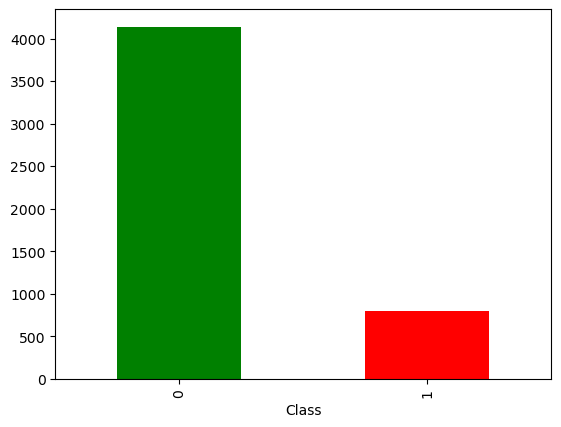

In [ ]:
y_train.value_counts().plot.bar(color=["green", "red"])

As we can see from the bar chart above, the non-churn customers are almost 4 times more than the churn customers, which makes it an imbalanced dataset as well. Since this dataset has 42 features, it would be better to use a more complex classification model and we choose to use `RandomForestClassifier` from `sklearn` package.


`RandomForestClassifier` has many hyperparameters that need to be tuned, we have pre-tuned the main parameters for you. You may also use the provided `grid_search_rf()` method to play with hyperparameter tuning yourself.


In [ ]:
# Tuned random forest parameters
best_params_no_weight = {
    "bootstrap": True,
    "class_weight": None,
    "max_depth": 10,
    "min_samples_split": 5,
    "n_estimators": 50,
}

Next, since we want to compare the performance of different models, we create a list to contain all model performance metrics.


In [90]:
results = []

#### **Train a regular random forest classifier**


Then, we will train a regular random forest classifier without any add-ons (class weights or resampling).


In [ ]:
preds, model = build_rf(
    X_train, y_train, X_test, best_params=best_params_no_weight
)
result = evaluate(y_test, preds, "Original")
print(result)
results.append(result)

{'type': 'Original', 'accuracy': 0.8623481781376519, 'recall': 0.28, 'auc': 0.6274396135265701, 'precision': 0.6829268292682927, 'fscore': 0.2865013774104683}


As you may expect, we have a very high prediction `accuracy` but even using a random forest classifier, our `recall` is very low with only 0.28. 
Next, let's try the class reweighting method to see if we can improve the performance.


#### **Class reweighting**


We will add class weights to the random forest classifier with pre-tuned weight 0.8 to churn class and weight 0.2 to non-churn class.


In [92]:
class_weight = {}
# 0.2 to Non-churn class
class_weight[0] = 0.2
# 0.8 to Churn class
class_weight[1] = 0.8

In [ ]:
# Pre-tuned hyper parameters
best_params_weight = {
    "bootstrap": True,
    "class_weight": class_weight,
    "max_depth": 10,
    "min_samples_split": 5,
    "n_estimators": 50,
}

Build a random forest model with the class weight 0.8 vs. 0.2.


In [ ]:
# class weight
preds_cw, weight_model = build_rf(
    X_train, y_train, X_test, best_params=best_params_weight
)

Then evaluate the refined model.


In [95]:
result = evaluate(y_test, preds_cw, "Class Weight")
print(result)
results.append(result)

{'type': 'Class Weight', 'accuracy': 0.8137651821862348, 'recall': 0.62, 'auc': 0.7356038647342995, 'precision': 0.4460431654676259, 'fscore': 0.6108374384236454}


As we can see from the evaluation results above, `Recall` and `Fscore` are significantly improved by adding class weights. Such improvements indicate that class reweighting is effective for the imbalanced customer churn dataset.


#### **Resampling: SMOTE and Undersampling**


Then, we want to use resampling to see if it is also able to improve the model performance.


First, we create resampled training datasets:


In [96]:
# X_smo is resampled from X_train using SMOTE
# y_smo is resampled from y_train using SMOTE
# X_under is resampled from X_train using Undersampling
# y_under is resampled from y_train using Undersampling
X_smo, y_smo, X_under, y_under = resample(X_train, y_train)

Then we can retrain a random forest classifier using SMOTE resampled input `X_smo` and output `y_smo` and evaluate its performance,


In [ ]:
preds_smo, smo_model = build_rf(
    X_smo, y_smo, X_test, best_params=best_params_no_weight
)
result = evaluate(y_test, preds_smo, "SMOTE")
print(result)
results.append(result)

{'type': 'SMOTE', 'accuracy': 0.8396761133603239, 'recall': 0.525, 'auc': 0.7127415458937197, 'precision': 0.5048076923076923, 'fscore': 0.5241935483870968}


and we can retrain a random forest classifier using the undersampled input `X_under` and output `y_under` and evaluate its performance.


In [ ]:
preds_under, under_model = build_rf(
    X_under, y_under, X_test, best_params=best_params_no_weight
)
result = evaluate(y_test, preds_under, "Undersampling")
print(result)
results.append(result)

{'type': 'Undersampling', 'accuracy': 0.7336032388663968, 'recall': 0.79, 'auc': 0.7563526570048309, 'precision': 0.3550561797752809, 'fscore': 0.7544536271808999}


#### **Compare the performance among different random forest models**


By now, we have built four different random forest models: the model trained with the original dataset, the model with class weights, the model trained with SMOTE dataset, and the model trained with undersampling. 

To better analyze and compare their performance, we can visualize the metrics using a grouped bar chart.


            type  accuracy  recall       auc  precision    fscore
0       Original  0.862348   0.280  0.627440   0.682927  0.286501
1   Class Weight  0.813765   0.620  0.735604   0.446043  0.610837
2          SMOTE  0.839676   0.525  0.712742   0.504808  0.524194
3  Undersampling  0.733603   0.790  0.756353   0.355056  0.754454


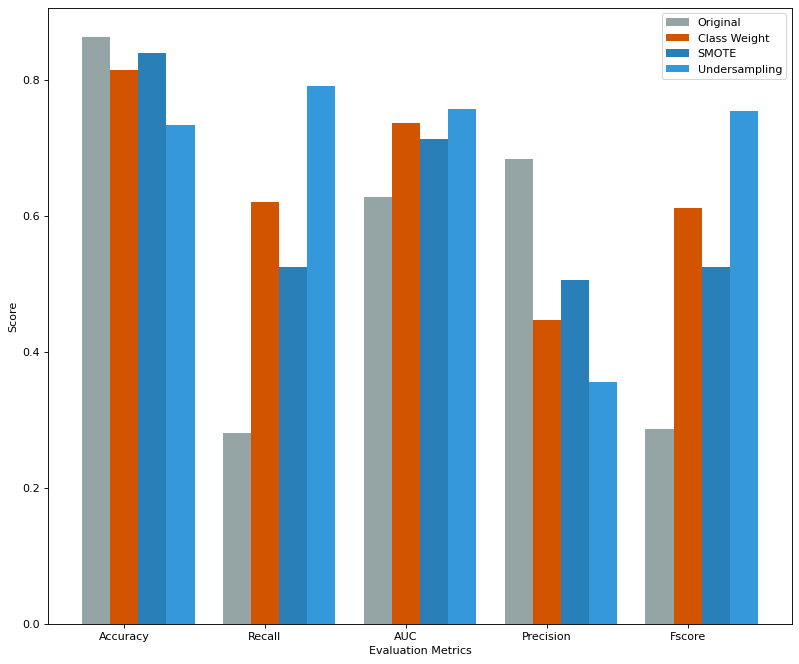

In [99]:
visualize_eval_metrics(results)

Let's first see what each color means. The grey bars represent the original model, the orange bars represent the model with class weight, the dark blue bars represent model trained with SMOTE, and the light blue bars represent the model trained with undersampling.

As we can infer the following insights from the bar charts:


- All models have high accuracy
- Recall is improved with class weights and resampling methods, and undersampling produces the highest recall
- AUC is also improved with class weights and resampling methods, and undersampling produces the highest AUC again
- Precisions are decreased with class weights and resampling methods as they all introduced many false positives (which are expected as we are trying to increase the impact of the positive class)
- Fscore is improved with class weights and resampling method, and undersampling has the highest Fscore


By analyzing the bar chart above, we can see that undersampling seems to be the best method to help alleviate the imbalanced challenge in the customer churn dataset. Although all class weights, SMOTE, and undersampling decreased the precision (increased false positives) but sometimes it is not a bad idea to assume some of your customers are about to leave (even if they are not) as motivation to improve your services.


### **Scenario 3: Tumor Type Estimation**


Finally, let's see an interesting imbalanced dataset that has very high Precision, Recall, and F-score initially without using class reweighting and resampling.


This dataset contains tumor samples and we need to estimate/predict if a tumor sample is cancerous or not.

First, like other scenarios, let's load and split the dataset


In [ ]:
tumor_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML201EN-SkillsNetwork/labs/module_4/datasets/im_cancer.csv",
    index_col=False,
)
X_train, X_test, y_train, y_test = split_data(tumor_df)

and check its class distribution:


<Axes: xlabel='Class'>

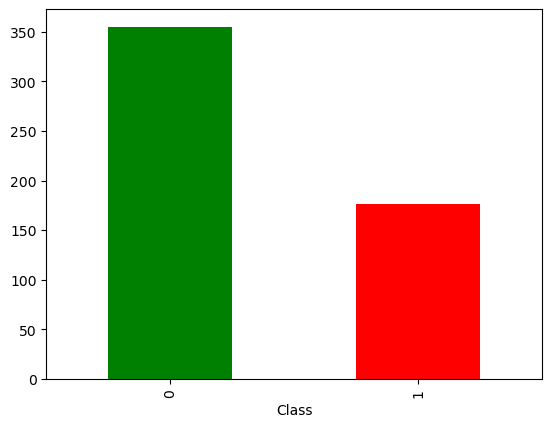

In [ ]:
y_train.value_counts().plot.bar(color=["green", "red"])

As we can see, this dataset is not as imbalanced as previous datasets. So that it is possible we dont need to use class reweighting and resampling in order to have good classification performance.


But we still create synthetic datasets with SMOTE and undersampling and class weights to compare their performance.


In [102]:
X_smo, y_smo, X_under, y_under = resample(X_train, y_train)

Use tuned random forest parameters.


In [ ]:
best_params_weight = {
    "bootstrap": True,
    "class_weight": {0: 0.2, 1: 0.8},
    "max_depth": 10,
    "min_samples_split": 5,
    "n_estimators": 50,
}

Train and evaluate different random forest models on the tumor type dataset.


In [ ]:
# no class-weights
results = []
preds, model = build_rf(X_train, y_train, X_test)
results.append(evaluate(y_test, preds))
# class weight
preds, model = build_rf(
    X_train, y_train, X_test, best_params=best_params_weight
)
results.append(evaluate(y_test, preds))
# Resampling
preds, model = build_rf(X_smo, y_smo, X_test)
results.append(evaluate(y_test, preds))
preds, model = build_rf(X_under, y_under, X_test)
results.append(evaluate(y_test, preds))

       type  accuracy  recall       auc  precision    fscore
0  Original  0.984962     1.0  0.988764   0.956522  0.998255
1  Original  0.992481     1.0  0.994382   0.977778  0.999127
2  Original  0.992481     1.0  0.994382   0.977778  0.999127
3  Original  0.984962     1.0  0.988764   0.956522  0.998255


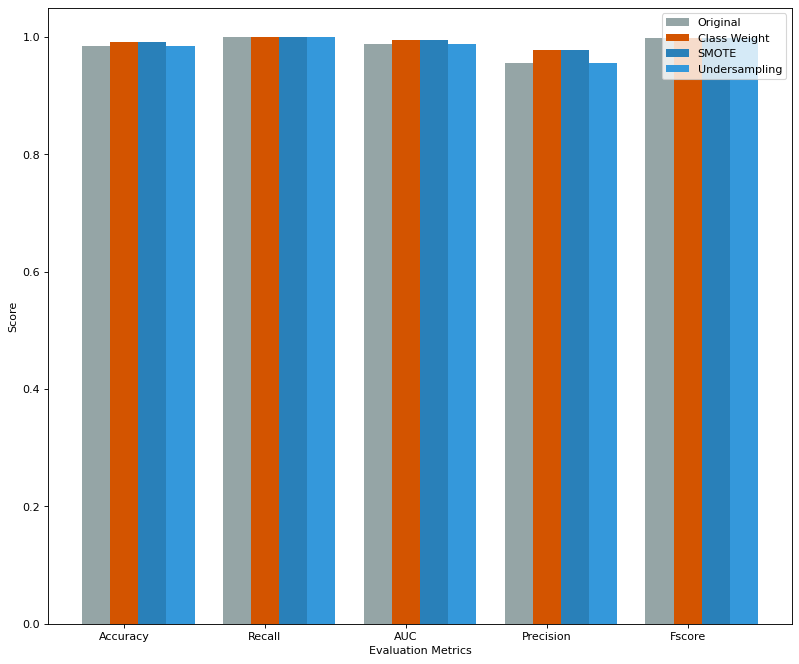

In [105]:
visualize_eval_metrics(results)

As we can see, all grey bars (the original model) for Accuracy, Recall, AUC, Precision, and F-score have very high values and adding class reweighting and resampling does not help improve performance that much. This is possible that the tumor patterns in this dataset are obvious and can be easily picked up by the standard random forest model or the dataset is not very imbalanced and can be considered as an ordinary binary classification task.


### **Exercise: Predicting Job Change**


Now it is time to apply what you have learned in this lab. We have an imbalanced HR dataset and we want to use it to build a classification model to predict if an employee is looking for a new job or not.


In [ ]:
# Load the dataset
hr_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML201EN-SkillsNetwork/labs/module_4/datasets/im_hr.csv",
    index_col=False,
)

#### **Check its class distribution**


       count  percent
Class                
0.0    14381    91.13
1.0     1400     8.87


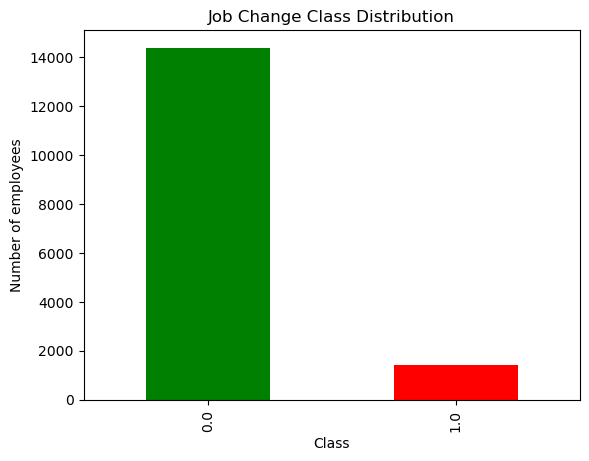

In [ ]:
# Check the target class distribution before modeling
class_counts = hr_df["Class"].value_counts().sort_index()
class_percent = hr_df["Class"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame(
    {"count": class_counts, "percent": class_percent.round(2)}
)
print(class_distribution)

class_counts.plot.bar(color=["green", "red"])
plt.title("Job Change Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of employees")
plt.show()

The split uses the existing `split_data()` helper, which applies `stratify=y`. Stratification matters here because it preserves the rare class proportion in both training and testing data. After splitting, the feature values are scaled with `MinMaxScaler` so logistic regression can converge more reliably.


#### **Split the dataset**


In [ ]:
# Split features and target with stratification so the train/test sets keep
# approximately the same imbalance ratio as the full HR dataset.
X_train, X_test, y_train, y_test = split_data(hr_df)

# Scale the HR features for logistic regression. Fit the scaler on the
# training set only, then transform the test set to avoid data leakage.
hr_scaler = MinMaxScaler()
feature_names = X_train.columns
X_train = pd.DataFrame(
    hr_scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
X_test = pd.DataFrame(
    hr_scaler.transform(X_test), columns=feature_names, index=X_test.index
)

print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training class distribution:
Class
0    0.911
1    0.089
Name: proportion, dtype: float64

Testing class distribution:
Class
0    0.911
1    0.089
Name: proportion, dtype: float64


The original logistic regression model is the baseline. Its metrics show how the model behaves before any imbalance-handling technique is added.


#### **Build a logistic regression model with the original dataset**


In [ ]:
# Baseline model: train logistic regression on the original imbalanced data.
results = []

preds_original, original_model = build_lr(X_train, y_train, X_test)
result = evaluate(y_test, preds_original, eval_type="Original")
print(result)
results.append(result)

{'type': 'Original', 'accuracy': 0.9116249604054482, 'recall': 0.0035714285714285713, 'auc': 0.5017857142857143, 'precision': 1.0, 'fscore': 0.0037137551778317385}


The class-weighted model keeps the original data distribution but changes the learning objective. By assigning class `1` a larger weight, the model is encouraged to catch more employees who are looking for a job change.


#### **Add class weights to the model**


In [ ]:
# Class weighting gives the minority class a larger penalty during training.
# The HR data is roughly 10:1, so this tuned 0.1/0.9 split emphasizes class 1.
best_params = {"class_weight": {0: 0.1, 1: 0.9}}

preds_weight, weight_model = build_lr(
    X_train, y_train, X_test, best_params=best_params
)
result = evaluate(y_test, preds_weight, eval_type="Class Weight")
print(result)
results.append(result)

{'type': 'Class Weight', 'accuracy': 0.7551472917326576, 'recall': 0.5678571428571428, 'auc': 0.6706160931525895, 'precision': 0.1960542540073983, 'fscore': 0.5292536166944053}


This cell creates the resampled datasets and trains logistic regression on the SMOTE-balanced training data. Resampling is applied only to `X_train` and `y_train`; the test set must remain unchanged to give an honest evaluation.


#### **Improve the model with SMOTE resampled dataset**


In [ ]:
# SMOTE creates synthetic minority-class examples from the training data only.
# The test set stays untouched so evaluation still reflects real data.
X_smo, y_smo, X_under, y_under = resample(X_train, y_train)

print("SMOTE-resampled training distribution:")
print(y_smo.value_counts().sort_index())

preds_smote, smote_model = build_lr(X_smo, y_smo, X_test)
result = evaluate(y_test, preds_smote, eval_type="SMOTE")
print(result)
results.append(result)

SMOTE-resampled training distribution:
Class
0    11504
1    11504
Name: count, dtype: int64
{'type': 'SMOTE', 'accuracy': 0.7120684193854926, 'recall': 0.6071428571428571, 'auc': 0.6647115050399722, 'precision': 0.17543859649122806, 'fscore': 0.5546492659053833}


This cell reuses the balanced training data created for SMOTE and evaluates random undersampling. Undersampling is useful as a comparison because it balances the classes in the opposite way: instead of adding minority-class examples, it removes majority-class examples.


#### **Improve the model with Undersampling resampled dataset**


Undersampled training distribution:
Class
0    1120
1    1120
Name: count, dtype: int64
{'type': 'Undersampling', 'accuracy': 0.7184035476718403, 'recall': 0.6, 'auc': 0.6649635036496351, 'precision': 0.17777777777777778, 'fscore': 0.5497797356828193}
            type  accuracy    recall       auc  precision    fscore
0       Original  0.911625  0.003571  0.501786   1.000000  0.003714
1   Class Weight  0.755147  0.567857  0.670616   0.196054  0.529254
2          SMOTE  0.712068  0.607143  0.664712   0.175439  0.554649
3  Undersampling  0.718404  0.600000  0.664964   0.177778  0.549780


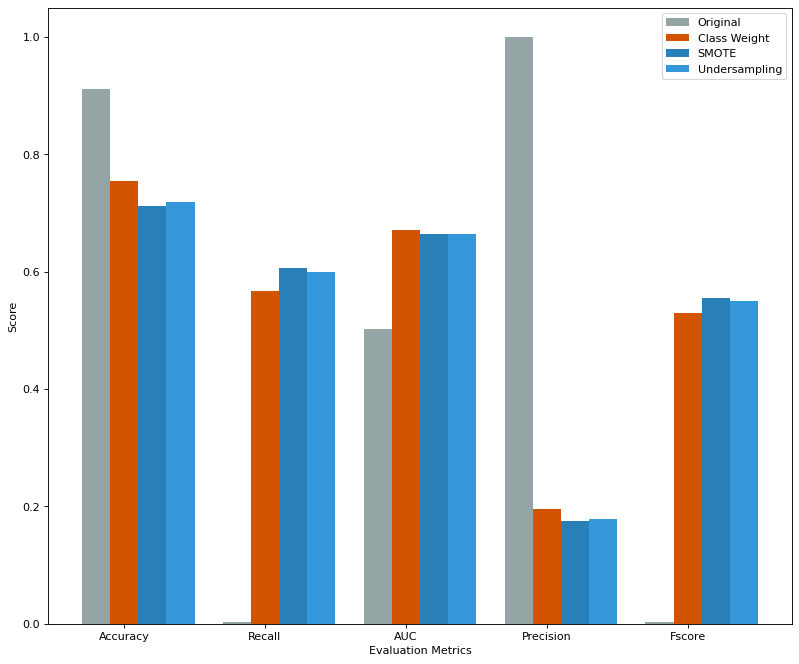

In [ ]:
# Random undersampling balances the classes by removing majority-class
# training rows, then trains the same logistic regression model.
print("Undersampled training distribution:")
print(y_under.value_counts().sort_index())

preds_under, under_model = build_lr(X_under, y_under, X_test)
result = evaluate(y_test, preds_under, eval_type="Undersampling")
print(result)
results.append(result)

visualize_eval_metrics(results)

#### **Findings**

The job-change dataset is imbalanced, so accuracy alone is not enough. The key trade-off is recall vs. precision.

- **Original**: baseline model, but likely misses many class `1` cases.
- **Class Weight**: improves recall by giving class `1` more importance.
- **SMOTE**: improves recall with synthetic class `1` samples, but may add false positives.
- **Undersampling**: improves recall by balancing classes, but uses less training data.

Choose the method with stronger recall and F-score if finding job changers is most important; choose higher precision if false alarms are more costly.


<details><summary>Click here for a solution</summary>

```python
y_train.value_counts().plot.bar(color=['green', 'red'])
best_params = {'class_weight': {0: 0.1, 1: 0.9}}
results = []
# no class-weights
preds, model = build_lr(X_train, y_train, X_test)
result = evaluate(y_test, preds)
results.append(result)
# class weight
preds, weight_model = build_lr(X_train, y_train, X_test, best_params=best_params)
result = evaluate(y_test, preds, eval_type="Class Weight")
results.append(result)
# Resampling
preds, smote_model = build_lr(X_smo, y_smo, X_test)
result = evaluate(y_test, preds, eval_type="SMOTE")
results.append(result)
preds_under, under_model = build_lr(X_under, y_under, X_test)
result = evaluate(y_test, preds_under, eval_type="Undersampling")
#metrics.plot_roc_curve(smote_model, X_test, y_test) 
results.append(result)
visualize_eval_metrics(results)
```

</details>


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


Copyright © 2021 IBM Corporation. All rights reserved.
